# E-commerce Analytics Pipeline

```
E-commerce Analytics Pipeline
==============================
A digital analytics case study for an e-commerce toy startup, structured the
way it would be presented internally:

  SECTION 0 - Setup, data load, cleaning
  SECTION 1 - DESCRIPTIVE ANALYSIS   (what happened)
  SECTION 2 - DIAGNOSTIC ANALYSIS    (why it happened)   -- mirrors Section 1's
                                                              headings 1:1
  SECTION 3 - PREDICTIVE ANALYSIS    (what's likely to happen) 



In [1]:
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns





C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


##  DATA LOAD & CLEANING

In [2]:
conn = pyodbc.connect(
    'Driver={SQL Server};'
    'Server=KOMAL\\SQLEXPRESS;'
    'Database=Ecommerce_Analytics_project;'
    'Trusted_connection=yes;'
)
cursor = conn.cursor()

sessions = pd.read_sql("SELECT * FROM website_sessions", conn)
orders = pd.read_sql("SELECT * FROM orders", conn)
order_items = pd.read_sql("SELECT * FROM orders_items", conn)
products = pd.read_sql("SELECT * FROM products", conn)
refunds = pd.read_sql("SELECT * FROM order_item_refunds", conn)
website_pageviews = pd.read_sql("SELECT * FROM website_pageviews", conn)

print(sessions.head())
print(orders.head())
print(order_items.head())
print(products.head())
print(refunds.head())
print(website_pageviews.head())



C:\Users\acer\AppData\Local\Temp\ipykernel_11780\4105844310.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sessions = pd.read_sql("SELECT * FROM website_sessions", conn)
C:\Users\acer\AppData\Local\Temp\ipykernel_11780\4105844310.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT * FROM orders", conn)
C:\Users\acer\AppData\Local\Temp\ipykernel_11780\4105844310.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql("SELECT * FROM orders_items", conn)
C:\Users\acer\A

   website_session_id          created_at  user_id  is_repeat_session  \
0                   1 2012-03-19 08:04:16        1                  0   
1                   2 2012-03-19 08:16:49        2                  0   
2                   3 2012-03-19 08:26:55        3                  0   
3                   4 2012-03-19 08:37:33        4                  0   
4                   5 2012-03-19 09:00:55        5                  0   

  utm_source utm_campaign utm_content device_type             http_referer  
0    gsearch     nonbrand      g_ad_1      mobile  https://www.gsearch.com  
1    gsearch     nonbrand      g_ad_1     desktop  https://www.gsearch.com  
2    gsearch     nonbrand      g_ad_1     desktop  https://www.gsearch.com  
3    gsearch     nonbrand      g_ad_1     desktop  https://www.gsearch.com  
4    gsearch     nonbrand      g_ad_1      mobile  https://www.gsearch.com  
   order_id          created_at  website_session_id  user_id  \
0         1 2012-03-19 10:42:46    

In [3]:
# --- Outlier handling (IQR capping, flagged not deleted) ---
for col in ['price_usd', 'cogs_usd', 'items_purchased']:
    q1, q3 = orders[col].quantile(0.25), orders[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = max(q1 - 1.5 * iqr, 0), q3 + 1.5 * iqr
    flag_col = col + "_was_outlier"
    orders[flag_col] = (orders[col] < lower) | (orders[col] > upper)
    n_flagged = orders[flag_col].sum()
    orders[col] = orders[col].clip(lower=lower, upper=upper)
    print(f'orders.{col}: bounds=({lower:.2f},{upper:.2f}), {n_flagged} rows capped')

for col in ['price_usd', 'cogs_usd']:
    q1, q3 = order_items[col].quantile(0.25), order_items[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = max(q1 - 1.5 * iqr, 0), q3 + 1.5 * iqr
    flag_col = col + "_was_outlier"
    order_items[flag_col] = (order_items[col] < lower) | (order_items[col] > upper)
    n_flagged = order_items[flag_col].sum()
    order_items[col] = order_items[col].clip(lower=lower, upper=upper)
    print(f'order_items.{col}: bounds=({lower:.2f},{upper:.2f}), {n_flagged} rows capped')

col = 'refund_amount_usd'
q1, q3 = refunds[col].quantile(0.25), refunds[col].quantile(0.75)
iqr = q3 - q1
lower, upper = max(q1 - 1.5 * iqr, 0), q3 + 1.5 * iqr
refunds[col + "_was_outlier"] = (refunds[col] < lower) | (refunds[col] > upper)
n_flagged = refunds[col + "_was_outlier"].sum()
refunds[col] = refunds[col].clip(lower=lower, upper=upper)
print(f'refunds.{col}: bounds=({lower:.2f},{upper:.2f}), {n_flagged} rows capped')


# ============================================================
# SECTION 1 - DESCRIPTIVE ANALYSIS (what happened)
# ============================================================

orders.price_usd: bounds=(34.99,74.99), 8246 rows capped
orders.cogs_usd: bounds=(14.99,26.99), 9623 rows capped
orders.items_purchased: bounds=(1.00,1.00), 7712 rows capped
order_items.price_usd: bounds=(49.99,49.99), 15799 rows capped
order_items.cogs_usd: bounds=(19.49,19.49), 15799 rows capped
refunds.refund_amount_usd: bounds=(49.99,49.99), 494 rows capped


## SECTION 1: DESCRIPTIVE ANALYSIS

### 1.1 Sales & Revenue Analysis

In [4]:
'''Q: What is our overall revenue and profitability position?'''
total_revenue = order_items['price_usd'].sum()
total_refund = refunds['refund_amount_usd'].sum()
net_revenue = total_revenue - total_refund
total_cogs = order_items['cogs_usd'].sum()
gross_margin = total_revenue - total_cogs
gross_margin_perc = gross_margin / total_revenue * 100

print('total_revenue:', round(total_revenue, 2))
print('total_refund:', round(total_refund, 2))
print('net_revenue:', round(net_revenue, 2))
print('total_cogs:', round(total_cogs, 2))
print('gross_margin:', round(gross_margin, 2))
print('gross_margin_%:', round(gross_margin_perc, 2))
print(f"insights: Net revenue stands at ${net_revenue:,.2f} after ${total_refund:,.2f} in refunds, "
      f"with a gross margin of {gross_margin_perc:.1f}%.")

total_revenue: 2000849.75
total_refund: 86532.69
net_revenue: 1914317.06
total_cogs: 780087.25
gross_margin: 1220762.5
gross_margin_%: 61.01
insights: Net revenue stands at $1,914,317.06 after $86,532.69 in refunds, with a gross margin of 61.0%.


In [5]:
'''Q: How has revenue trended month over month?'''
order_items['months'] = order_items['created_at'].dt.to_period('M').astype(str)
monthly_revenue = order_items.groupby('months')['price_usd'].sum().reset_index().sort_values('months')
monthly_revenue['sales_growth'] = monthly_revenue['price_usd'].pct_change()
print(monthly_revenue.to_string(index=False))
print(f"insights: Revenue moved from ${monthly_revenue['price_usd'].iloc[0]:,.0f} to "
      f"${monthly_revenue['price_usd'].iloc[-1]:,.0f} over the period — "
      f"{'net growth' if monthly_revenue['price_usd'].iloc[-1] > monthly_revenue['price_usd'].iloc[0] else 'net decline'} overall.")


 months  price_usd  sales_growth
2012-03    2999.40           NaN
2012-04    4949.01      0.650000
2012-05    5398.92      0.090909
2012-06    6998.60      0.296296
2012-07    8448.31      0.207143
2012-08   11397.72      0.349112
2012-09   14347.13      0.258772
2012-10   18546.29      0.292683
2012-11   30893.82      0.665768
2012-12   25294.94     -0.181230
2013-01   19496.10     -0.229249
2013-02   24895.02      0.276923
2013-03   19246.15     -0.226908
2013-04   27644.47      0.436364
2013-05   28544.29      0.032550
2013-06   29644.07      0.038529
2013-07   30193.96      0.018550
2013-08   30393.92      0.006623
2013-09   31743.65      0.044408
2013-10   36892.62      0.162205
2013-11   44891.02      0.216802
2013-12   56988.60      0.269488
2014-01   55538.89     -0.025439
2014-02   67386.52      0.213321
2014-03   71335.73      0.058605
2014-04   82833.43      0.161177
2014-05   93631.27      0.130356
2014-06   83733.25     -0.105713
2014-07   87232.55      0.041791
2014-08   

quarter  price_usd
 2012Q1    2999.40
 2012Q2   17346.53
 2012Q3   34193.16
 2012Q4   74735.05
 2013Q1   66377.27
 2013Q2   88492.83
 2013Q3   95031.59
 2013Q4  138211.84
 2014Q1  177510.31
 2014Q2  229012.52
 2014Q3  240820.65
 2014Q4  349684.92
 2015Q1  316784.80


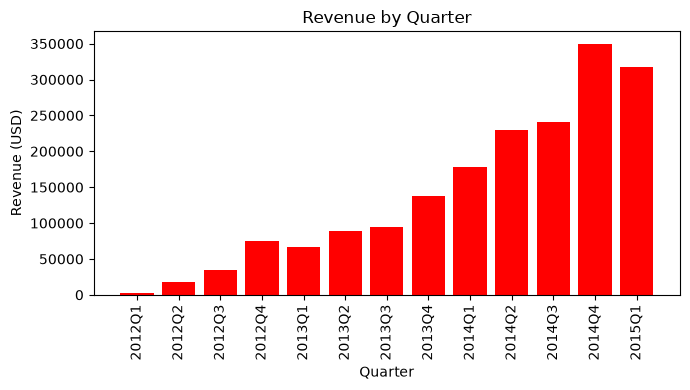

insights: 2014Q4 is the strongest quarter ($349,684.92).


In [6]:
'''Q: Which quarter generates the most revenue?'''
orders['quarter'] = orders['created_at'].dt.to_period('Q').astype(str)
revenue_by_quarter = orders.groupby('quarter')['price_usd'].sum().reset_index().sort_values('quarter')
print(revenue_by_quarter.to_string(index=False))
plt.figure(figsize=(7, 4))
plt.bar(revenue_by_quarter['quarter'], revenue_by_quarter['price_usd'], color='red')
plt.title('Revenue by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
top_quarter = revenue_by_quarter.loc[revenue_by_quarter['price_usd'].idxmax()]
print(f"insights: {top_quarter['quarter']} is the strongest quarter (${top_quarter['price_usd']:,.2f}).")



-- price distribution --
count    4.002500e+04
mean     4.999000e+01
std      8.555041e-12
min      4.999000e+01
25%      4.999000e+01
50%      4.999000e+01
75%      4.999000e+01
max      4.999000e+01

-- cost distribution --
count    4.002500e+04
mean     1.949000e+01
std      7.361315e-12
min      1.949000e+01
25%      1.949000e+01
50%      1.949000e+01
75%      1.949000e+01
max      1.949000e+01


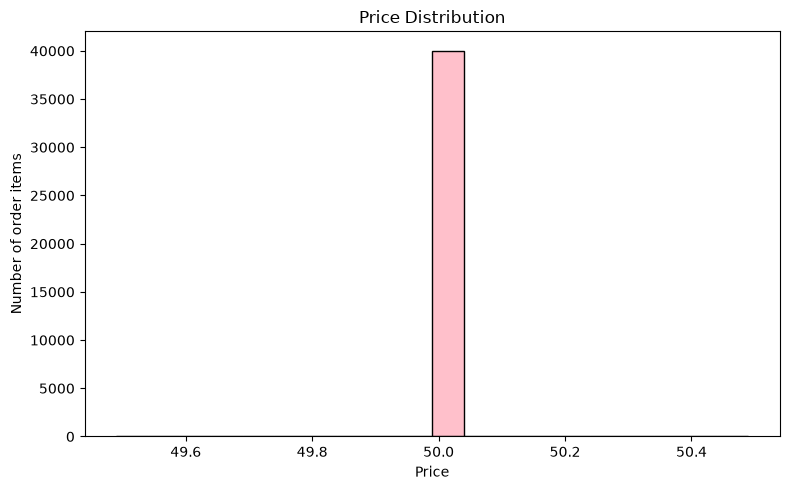

insights: Typical item price sits around $49.99 (median), ranging from $49.99 to $49.99.


In [7]:
'''Q: What's the typical price point and cost spread of items sold?'''
price_dist = order_items['price_usd'].describe()
cogs_dist = order_items['cogs_usd'].describe()
print('\n-- price distribution --')
print(price_dist.to_string())
print('\n-- cost distribution --')
print(cogs_dist.to_string())
plt.figure(figsize=(8, 5))
plt.hist(order_items['price_usd'], bins=20, color='pink', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of order items')
plt.tight_layout()
plt.show()
print(f"insights: Typical item price sits around ${price_dist['50%']:.2f} (median), "
      f"ranging from ${price_dist['min']:.2f} to ${price_dist['max']:.2f}.")


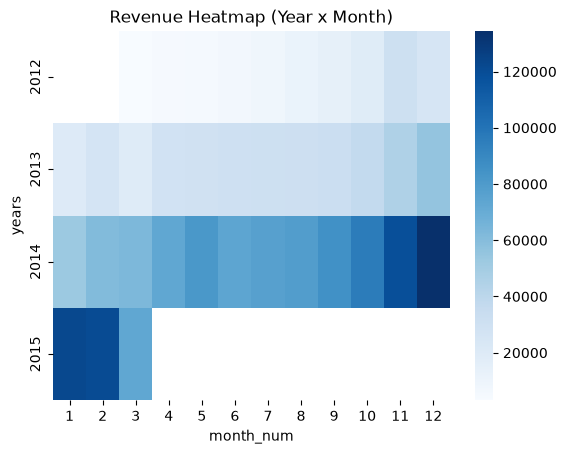

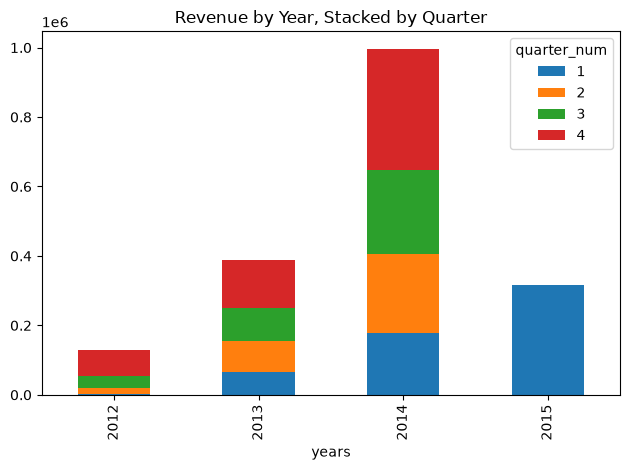

insights: The heatmap/stacked chart shows whether growth is broad-based across the year or concentrated in specific months.


In [8]:
'''Q: Is revenue consistent across years and quarters, or seasonal?'''
orders['years'] = orders['created_at'].dt.year
orders['month_num'] = orders['created_at'].dt.month
heatmap_data = orders.pivot_table(index='years', columns='month_num', values='price_usd', aggfunc='sum')
sns.heatmap(heatmap_data, cmap='Blues')
plt.title('Revenue Heatmap (Year x Month)')
plt.show()
quarter_data = orders.groupby(['years', orders['created_at'].dt.quarter])['price_usd'].sum().reset_index()
quarter_data.columns = ['years', 'quarter_num', 'price_usd']
quarter_pivot = quarter_data.pivot(index='years', columns='quarter_num', values='price_usd')
quarter_pivot.plot(kind='bar', stacked=True)
plt.title('Revenue by Year, Stacked by Quarter')
plt.tight_layout()
plt.show()
print("insights: The heatmap/stacked chart shows whether growth is broad-based across the year "
      "or concentrated in specific months.")


In [9]:
'''Q: Which months had the sharpest revenue swings month-over-month?'''
monthly_revenue['pct_change'] = monthly_revenue['price_usd'].pct_change().round(2)
swing_threshold = monthly_revenue['pct_change'].std()
biggest_jump = monthly_revenue.loc[monthly_revenue['pct_change'].idxmax()]
biggest_drop = monthly_revenue.loc[monthly_revenue['pct_change'].idxmin()]
print(monthly_revenue[['months', 'price_usd', 'pct_change']].to_string(index=False))
print(f"insights: Sharpest jump was {biggest_jump['months']} ({biggest_jump['pct_change']:+.2f}%), "
      f"sharpest drop was {biggest_drop['months']} ({biggest_drop['pct_change']:+.2f}%). "
      f"A swing bigger than {swing_threshold:.2f} is outside the usual month-to-month range.")

 months  price_usd  pct_change
2012-03    2999.40         NaN
2012-04    4949.01        0.65
2012-05    5398.92        0.09
2012-06    6998.60        0.30
2012-07    8448.31        0.21
2012-08   11397.72        0.35
2012-09   14347.13        0.26
2012-10   18546.29        0.29
2012-11   30893.82        0.67
2012-12   25294.94       -0.18
2013-01   19496.10       -0.23
2013-02   24895.02        0.28
2013-03   19246.15       -0.23
2013-04   27644.47        0.44
2013-05   28544.29        0.03
2013-06   29644.07        0.04
2013-07   30193.96        0.02
2013-08   30393.92        0.01
2013-09   31743.65        0.04
2013-10   36892.62        0.16
2013-11   44891.02        0.22
2013-12   56988.60        0.27
2014-01   55538.89       -0.03
2014-02   67386.52        0.21
2014-03   71335.73        0.06
2014-04   82833.43        0.16
2014-05   93631.27        0.13
2014-06   83733.25       -0.11
2014-07   87232.55        0.04
2014-08   89582.08        0.03
2014-09   97530.49        0.09
2014-10 

### 1.2 Order Analysis

In [10]:
'''Q: How many orders are we getting, and what's the average order value and conversion rate?'''
total_orders = orders['order_id'].nunique()
total_session = sessions['website_session_id'].nunique()
conversion_rate = total_orders / total_session * 100
avg_value_order = orders['price_usd'].sum() / total_orders
print('total_orders:', total_orders)
print('total_sessions:', total_session)
print('conversion_rate_%:', round(conversion_rate, 2))
print('avg_order_value:', round(avg_value_order, 2))
print(f"insights: {total_orders:,} orders from {total_session:,} sessions "
      f"({conversion_rate:.2f}% conversion), averaging ${avg_value_order:.2f} per order.")

total_orders: 32313
total_sessions: 472871
conversion_rate_%: 6.83
avg_order_value: 56.67
insights: 32,313 orders from 472,871 sessions (6.83% conversion), averaging $56.67 per order.


created_at  order_count   revenue
   2012-03           60   2999.40
   2012-04           99   4949.01
   2012-05          108   5398.92
   2012-06          140   6998.60
   2012-07          169   8448.31
   2012-08          228  11397.72
   2012-09          287  14347.13
   2012-10          371  18546.29
   2012-11          618  30893.82
   2012-12          506  25294.94
   2013-01          390  19966.10
   2013-02          498  26515.02
   2013-03          385  19896.15
   2013-04          553  28584.47
   2013-05          571  29364.29
   2013-06          593  30544.07
   2013-07          604  31143.96
   2013-08          608  31373.92
   2013-09          629  32513.71
   2013-10          708  37192.92
   2013-11          861  45336.39
   2013-12         1047  55682.53
   2014-01          982  53193.18
   2014-02         1021  61240.79
   2014-03         1066  63076.34
   2014-04         1241  73225.59
   2014-05         1368  81909.32
   2014-06         1239  73877.61
   2014-07    

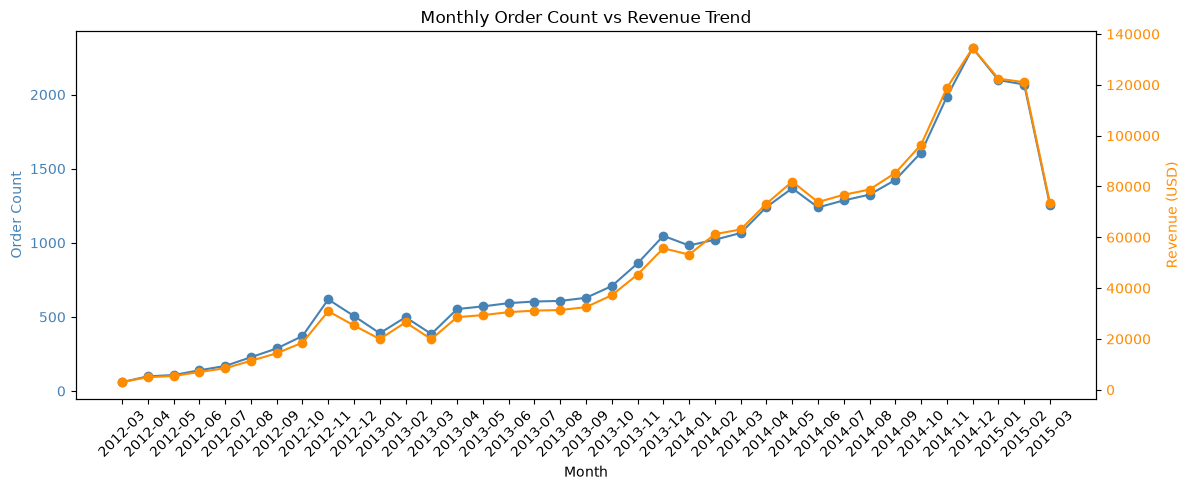

insights: Order count and revenue trends are plotted together above for a visual read on whether they move in lockstep.


In [11]:
'''Q: Does order count trend track with revenue?'''
order_trend = orders.groupby(orders['created_at'].dt.to_period('M')).agg(
    order_count=('order_id', 'nunique'), revenue=('price_usd', 'sum')).reset_index()
order_trend['created_at'] = order_trend['created_at'].astype(str)
print(order_trend.to_string(index=False))
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(order_trend['created_at'], order_trend['order_count'], color='steelblue', marker='o', label='Order Count')
ax1.set_xlabel('Month')
ax1.set_ylabel('Order Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
plt.xticks(rotation=45)
ax2 = ax1.twinx()
ax2.plot(order_trend['created_at'], order_trend['revenue'], color='darkorange', marker='o', label='Revenue')
ax2.set_ylabel('Revenue (USD)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
plt.title('Monthly Order Count vs Revenue Trend')
fig.tight_layout()
plt.show()
print(f"insights: Order count and revenue trends are plotted together above for a visual read "
      f"on whether they move in lockstep.")


Q: Is average order value (AOV) rising or declining over time?


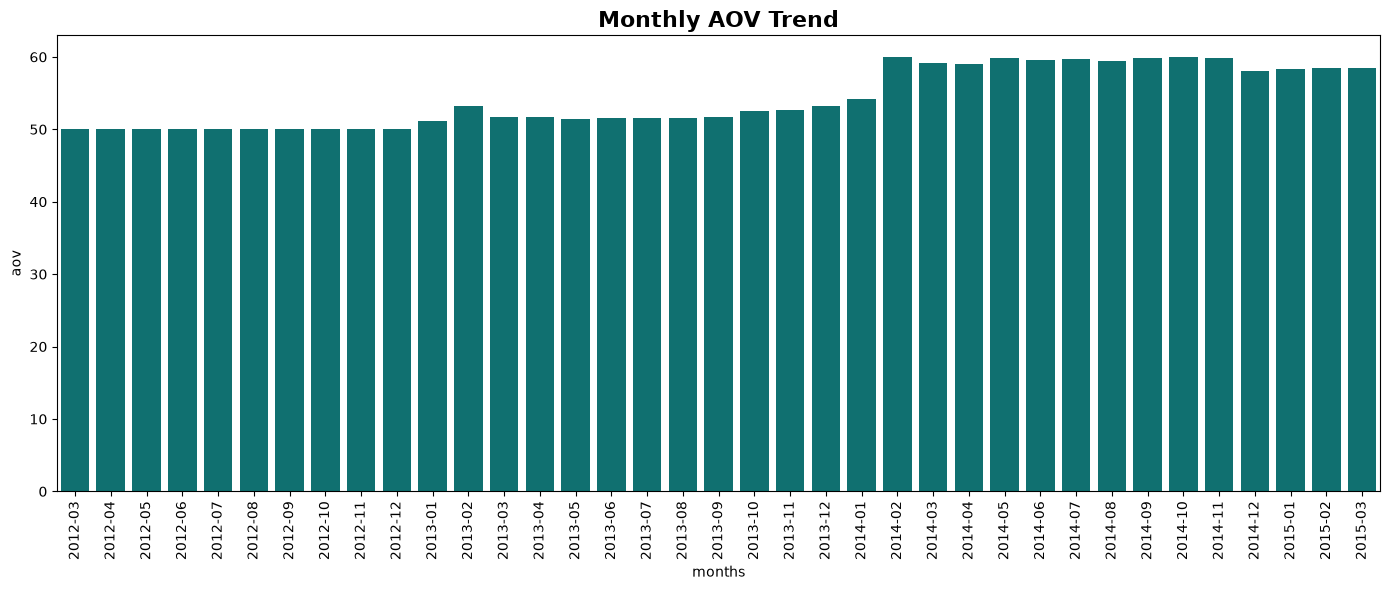

insights: AOV moved from $49.99 to $58.47 over the period.


In [12]:
print("\nQ: Is average order value (AOV) rising or declining over time?")
aov_trend = orders.groupby(orders['created_at'].dt.to_period('M')).agg(
    order_count=('order_id', 'nunique'), sales=('price_usd', 'sum')).reset_index()
aov_trend['aov'] = aov_trend['sales'] / aov_trend['order_count']
aov_trend['months'] = aov_trend['created_at'].astype(str)
plt.figure(figsize=(14, 6))
sns.barplot(data=aov_trend, x='months', y='aov', color='teal')
plt.xticks(rotation=90)
plt.title('Monthly AOV Trend', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()
print(f"insights: AOV moved from ${aov_trend['aov'].iloc[0]:.2f} to ${aov_trend['aov'].iloc[-1]:.2f} "
      f"over the period.")


 items_purchased  num_orders
               1       32313


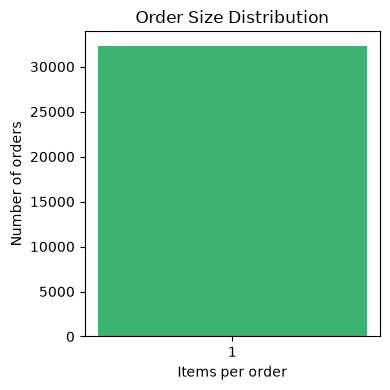

insights: Most orders contain 1 item(s) (32313 orders).


In [13]:
'''Q: How many items do customers typically buy per order?'''
order_size_distribution = orders['items_purchased'].value_counts().sort_index().reset_index()
order_size_distribution.columns = ['items_purchased', 'num_orders']
print(order_size_distribution.to_string(index=False))
plt.figure(figsize=(4, 4))
plt.bar(order_size_distribution['items_purchased'].astype(str), order_size_distribution['num_orders'], color='mediumseagreen')
plt.title('Order Size Distribution')
plt.xlabel('Items per order')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()
most_common_size = order_size_distribution.loc[order_size_distribution['num_orders'].idxmax()]
print(f"insights: Most orders contain {most_common_size['items_purchased']} item(s) "
      f"({most_common_size['num_orders']} orders).")

 weekdays  days_sales  days_contribution
   Monday   320735.38          17.515030
   Friday   314730.29          17.187098
Wednesday   310946.01          16.980442
 Thursday   307682.86          16.802245
  Tuesday   302439.80          16.515927
   Sunday   144165.62           7.872737
 Saturday   130500.91           7.126521


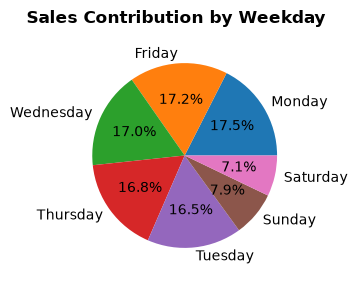

insights: Monday contributes the most sales (17.5% of total).


In [14]:
'''Q: Are certain days of the week consistently stronger for order volume?'''
orders['weekdays'] = orders['created_at'].dt.day_name()
volume_distribution = orders.groupby('weekdays')['price_usd'].sum().reset_index(name='days_sales')
volume_distribution = volume_distribution.sort_values(by='days_sales', ascending=False)
volume_distribution['days_contribution'] = volume_distribution['days_sales'] / volume_distribution['days_sales'].sum() * 100
print(volume_distribution.to_string(index=False))
plt.figure(figsize=(7, 3))
plt.pie(x=volume_distribution['days_contribution'], labels=volume_distribution['weekdays'], autopct='%1.1f%%')
plt.suptitle('Sales Contribution by Weekday', fontweight='bold')
plt.show()
top_day = volume_distribution.iloc[0]
print(f"insights: {top_day['weekdays']} contributes the most sales ({top_day['days_contribution']:.1f}% of total).")

### 1.3 Product Analysis

              product_name  units_sold    revenue
    The Original Mr. Fuzzy       24226 1211057.74
     The Forever Love Bear        5796  289742.04
The Hudson River Mini bear        5018  250849.82
  The Birthday Sugar Panda        4985  249200.15


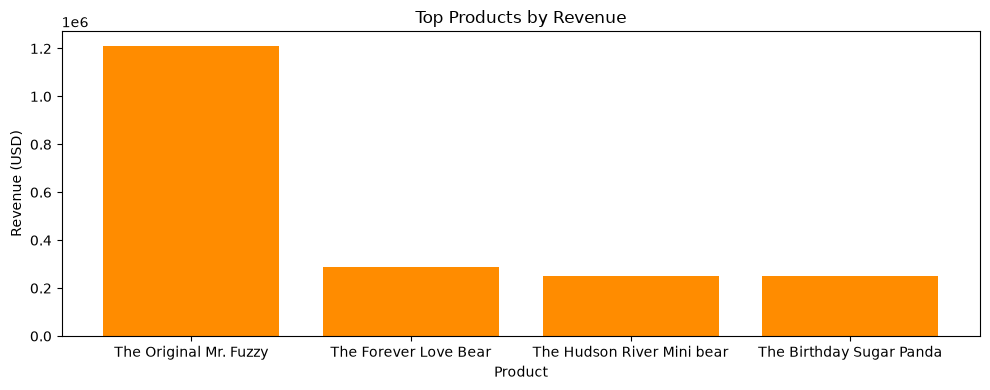

insights: The Original Mr. Fuzzy is the top seller ($1,211,057.74 from 24226 units).


In [15]:
'''Q: Which products drive the most revenue?")'''
merged3 = order_items.merge(products, on='product_id')
top_products = merged3.groupby('product_name').agg(
    units_sold=('order_item_id', 'nunique'), revenue=('price_usd', 'sum')).reset_index().sort_values('revenue', ascending=False)
print(top_products.to_string(index=False))
plt.figure(figsize=(10, 4))
plt.bar(top_products["product_name"], top_products["revenue"], color="darkorange")
plt.title("Top Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()
best_product = top_products.iloc[0]
print(f"insights: {best_product['product_name']} is the top seller "
      f"(${best_product['revenue']:,.2f} from {best_product['units_sold']} units).")

### 1.4 Traffic & Channel Analysis

In [16]:
'''Q: Does traffic track with revenue month to month, or do they move independently?'''
sessions['months'] = sessions['created_at'].dt.to_period('M').astype(str)
monthly_sessions = sessions.groupby('months').size().reset_index(name='sessions').sort_values('months')
print(monthly_sessions.to_string(index=False))
busy_month = monthly_sessions.loc[monthly_sessions['sessions'].idxmax()]
quiet_month = monthly_sessions.loc[monthly_sessions['sessions'].idxmin()]
print(f"insights: {busy_month['months']} had the most traffic ({busy_month['sessions']} sessions), "
      f"{quiet_month['months']} had the least ({quiet_month['sessions']} sessions).")

 months  sessions
2012-03      1879
2012-04      3734
2012-05      3736
2012-06      3963
2012-07      4249
2012-08      6097
2012-09      6546
2012-10      8183
2012-11     14011
2012-12     10072
2013-01      6401
2013-02      7168
2013-03      6264
2013-04      7971
2013-05      8449
2013-06      8325
2013-07      8903
2013-08      9180
2013-09      9580
2013-10     10773
2013-11     14032
2013-12     15735
2014-01     14825
2014-02     16285
2014-03     15669
2014-04     17353
2014-05     18061
2014-06     17715
2014-07     19038
2014-08     18590
2014-09     19513
2014-10     21526
2014-11     25125
2014-12     29722
2015-01     25337
2015-02     23778
2015-03     15083
insights: 2014-12 had the most traffic (29722 sessions), 2012-03 had the least (1879 sessions).


utm_source  orders    revenue
   gsearch   21333 1315286.89
   unknown    6118  384773.03
   bsearch    4519  277444.50
socialbook     343   23345.33


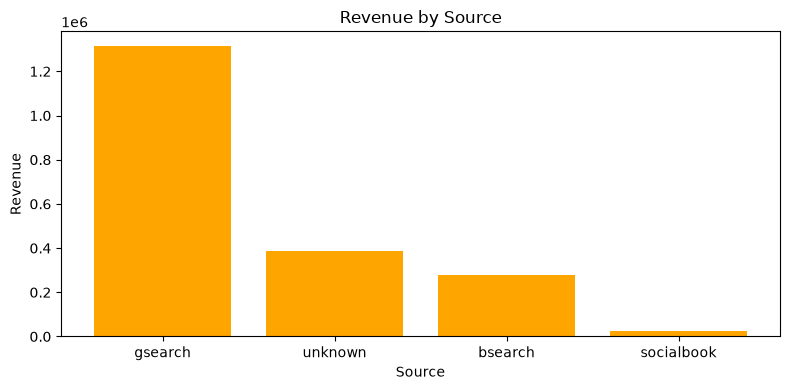

insights: gsearch brings in the most revenue ($1,315,286.89 from 21333 orders).


In [17]:
'''Q: Which acquisition channel (utm_source) brings in the most revenue?'''
merged = sessions[['website_session_id', 'utm_source']].merge(orders[['order_id', 'website_session_id']], on='website_session_id')
merged = merged.merge(order_items[['order_id', 'price_usd']], on='order_id')
revenue_by_source = merged.groupby('utm_source').agg(
    orders=('order_id', 'nunique'), revenue=('price_usd', 'sum')).reset_index().sort_values('revenue', ascending=False)
print(revenue_by_source.to_string(index=False))
plt.figure(figsize=(8, 4))
plt.bar(revenue_by_source['utm_source'], revenue_by_source['revenue'], color='orange')
plt.title('Revenue by Source')
plt.xlabel('Source')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()
top_source = revenue_by_source.iloc[0]
print(f"insights: {top_source['utm_source']} brings in the most revenue "
      f"(${top_source['revenue']:,.2f} from {top_source['orders']} orders).")

device_type  orders    revenue
    desktop   27805 1720455.84
     mobile    4508  280393.91


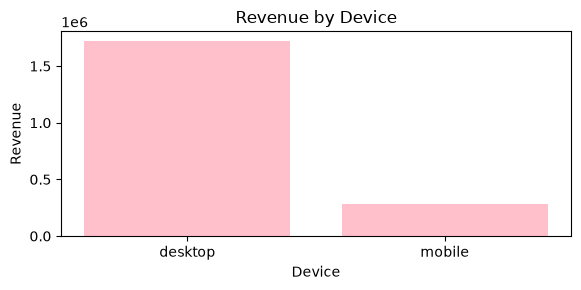

insights: desktop generates the most revenue ($1,720,455.84).


In [18]:
'''Q: Which device type generates the most revenue?'''
merged2 = sessions[['website_session_id', 'device_type']].merge(orders[['order_id', 'website_session_id']], on='website_session_id')
merged2 = merged2.merge(order_items[['order_id', 'price_usd']], on='order_id')
revenue_by_device = merged2.groupby('device_type').agg(
    orders=('order_id', 'nunique'), revenue=('price_usd', 'sum')).reset_index().sort_values('revenue', ascending=False)
print(revenue_by_device.to_string(index=False))
plt.figure(figsize=(6, 3))
plt.bar(revenue_by_device['device_type'], revenue_by_device['revenue'], color='pink')
plt.title('Revenue by Device')
plt.xlabel('Device')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()
top_device = revenue_by_device.iloc[0]
print(f"insights: {top_device['device_type']} generates the most revenue (${top_device['revenue']:,.2f}).")


-- session mix by source --
utm_source  pct_of_sessions
   gsearch             0.67
   unknown             0.18
   bsearch             0.13
socialbook             0.02

-- session mix by device --
device_type  pct_of_sessions
    desktop             0.69
     mobile             0.31


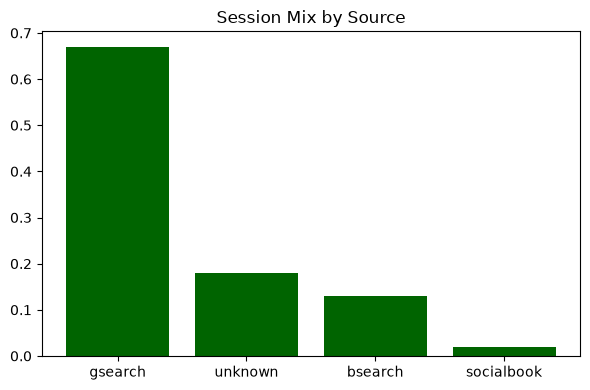

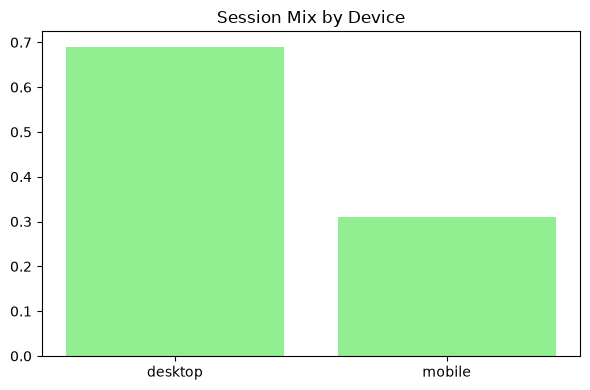

insights: gsearch sends the most traffic (67% of sessions); desktop sends the most traffic (69% of sessions).


In [19]:
'''Q: Where does our traffic actually come from — channel and device mix?'''
source_mix = sessions['utm_source'].value_counts(normalize=True).round(2).reset_index()
source_mix.columns = ['utm_source', 'pct_of_sessions']
device_mix = sessions['device_type'].value_counts(normalize=True).round(2).reset_index()
device_mix.columns = ['device_type', 'pct_of_sessions']
print('\n-- session mix by source --')
print(source_mix.to_string(index=False))
print('\n-- session mix by device --')
print(device_mix.to_string(index=False))
plt.figure(figsize=(6, 4))
plt.bar(source_mix['utm_source'], source_mix['pct_of_sessions'], color='darkgreen')
plt.title('Session Mix by Source')
plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 4))
plt.bar(device_mix['device_type'], device_mix['pct_of_sessions'], color='lightgreen')
plt.title('Session Mix by Device')
plt.tight_layout()
plt.show()
top_traffic_source = source_mix.iloc[0]
top_traffic_device = device_mix.iloc[0]
print(f"insights: {top_traffic_source['utm_source']} sends the most traffic "
      f"({top_traffic_source['pct_of_sessions'] * 100:.0f}% of sessions); "
      f"{top_traffic_device['device_type']} sends the most traffic "
      f"({top_traffic_device['pct_of_sessions'] * 100:.0f}% of sessions).")

### 1.5 Customer / Visitor Analysis

 label  pct_of_sessions  num_sessions
   new            83.39        394318
repeat            16.61         78553


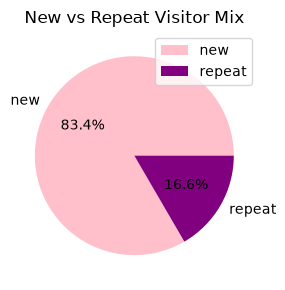

insights: Repeat visitors make up 16.61% of all sessions.


In [20]:
'''Q: What share of our sessions are new vs. repeat visitors?'''
session_mix = sessions['is_repeat_session'].value_counts().reset_index()
session_mix.columns = ['is_repeat_session', 'num_sessions']
session_mix['label'] = session_mix['is_repeat_session'].map({0: "new", 1: "repeat"})
session_mix['pct_of_sessions'] = (session_mix['num_sessions'] / session_mix['num_sessions'].sum() * 100).round(2)
print(session_mix[['label', 'pct_of_sessions', 'num_sessions']].to_string(index=False))
plt.figure(figsize=(5, 3))
plt.pie(session_mix['num_sessions'], labels=session_mix['label'], autopct='%1.1f%%', colors=['pink', 'purple'])
plt.title('New vs Repeat Visitor Mix')
plt.legend()
plt.tight_layout()
plt.show()
repeat_pct = session_mix.loc[session_mix['label'] == 'repeat', 'pct_of_sessions'].values[0]
print(f"insights: Repeat visitors make up {repeat_pct}% of all sessions.")

### 1.6 Refund Analysis

  month  refund_amount_usd
2012-04             249.95
2012-05             249.95
2012-06             249.95
2012-07             649.87
2012-08             899.82
2012-09            1049.79
2012-10            1199.76
2012-11            1999.60
2012-12            1899.62
2013-01            1049.79
2013-02            1149.77
2013-03            1049.79
2013-04            1149.77
2013-05            1549.69
2013-06            1699.66
2013-07            2249.55
2013-08            1749.65
2013-09            1199.76
2013-10             949.81
2013-11             899.82
2013-12            2249.55
2014-01            1799.64
2014-02            2449.51
2014-03            2249.55
2014-04            2749.45
2014-05            2549.49
2014-06            3449.31
2014-07            3899.22
2014-08            4649.07
2014-09           11847.63
2014-10            2999.40
2014-11            3249.35
2014-12            6098.78
2015-01            4999.00
2015-02            3949.21
2015-03            4099.18
2

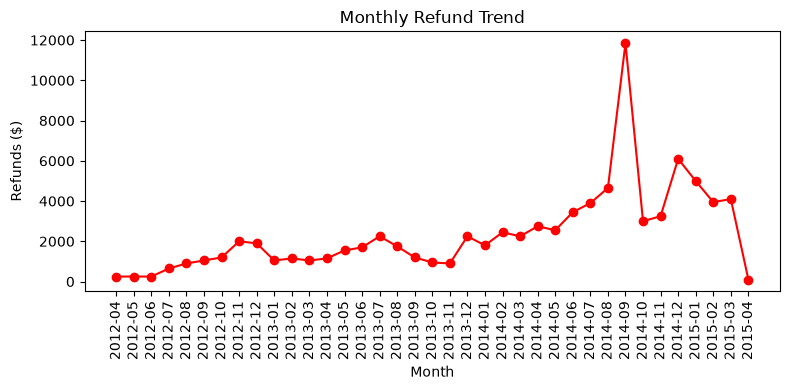

insights: 2014-09 had the highest refund total ($11847.63).


In [21]:
'''Q: How have refunds trended over time — any spikes to flag?'''
refunds['created_at'] = pd.to_datetime(refunds['created_at'])
refunds['month'] = refunds['created_at'].dt.to_period('M').astype(str)
monthly_refunds = refunds.groupby('month')['refund_amount_usd'].sum().reset_index().sort_values('month')
print(monthly_refunds.to_string(index=False))
plt.figure(figsize=(8, 4))
plt.plot(monthly_refunds['month'], monthly_refunds['refund_amount_usd'], marker='o', color='red')
plt.title('Monthly Refund Trend')
plt.xlabel('Month')
plt.ylabel('Refunds ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
worst_refund_month = monthly_refunds.loc[monthly_refunds['refund_amount_usd'].idxmax()]
print(f"insights: {worst_refund_month['month']} had the highest refund total "
      f"(${worst_refund_month['refund_amount_usd']:.2f}).")

### SECTION 1 SUMMARY — Descriptive Analysis

In [22]:
def insights(points):
    """Print a bullet-point conclusion. `points` is a list of strings."""
    print("insights:")
    for p in points:
        print(f"  - {p}")

In [23]:
print("Q: Overall, what does the descriptive data tell us happened in the business?")
insights([
    f"Net revenue: ${net_revenue:,.2f} at a {gross_margin_perc:.1f}% gross margin, "
    f"with {total_orders:,} orders from {total_session:,} sessions ({conversion_rate:.2f}% conversion).",
    f"Strongest quarter: {top_quarter['quarter']}. Best-selling product: {best_product['product_name']}.",
    f"Top traffic/revenue channel: {top_source['utm_source']}. Top device: {top_device['device_type']}.",
    f"Repeat visitors are {repeat_pct}% of sessions. Highest refund month: {worst_refund_month['month']}.",
    "Overall the business shows a clear revenue leader by channel/product/quarter — the Diagnostic section "
    "below investigates the 'why' behind these numbers.",
])




Q: Overall, what does the descriptive data tell us happened in the business?
insights:
  - Net revenue: $1,914,317.06 at a 61.0% gross margin, with 32,313 orders from 472,871 sessions (6.83% conversion).
  - Strongest quarter: 2014Q4. Best-selling product: The Original Mr. Fuzzy.
  - Top traffic/revenue channel: gsearch. Top device: desktop.
  - Repeat visitors are 16.61% of sessions. Highest refund month: 2014-09.
  - Overall the business shows a clear revenue leader by channel/product/quarter — the Diagnostic section below investigates the 'why' behind these numbers.


## SECTION 2: DIAGNOSTIC ANALYSIS

### 2.1 Sales & Revenue Diagnostics

In [24]:
'''Q: Does session traffic explain the month-to-month revenue trend, or is revenue driven by something else?'''
rev_vs_sessions = monthly_revenue[['months', 'price_usd']].merge(
    monthly_sessions, on='months', how='inner')
traffic_revenue_corr = rev_vs_sessions['price_usd'].corr(rev_vs_sessions['sessions'])
print(rev_vs_sessions.to_string(index=False))
print(f"Correlation (monthly sessions vs monthly revenue): {traffic_revenue_corr:.2f}")
insights([
    f"Sessions and revenue have a {traffic_revenue_corr:.2f} correlation month-to-month.",
    "A strong positive value (close to 1) means revenue is mostly a volume story — more traffic, more revenue.",
    "A weaker value means revenue swings are being driven by something else too, like AOV or conversion rate, not just traffic.",
])



 months  price_usd  sessions
2012-03    2999.40      1879
2012-04    4949.01      3734
2012-05    5398.92      3736
2012-06    6998.60      3963
2012-07    8448.31      4249
2012-08   11397.72      6097
2012-09   14347.13      6546
2012-10   18546.29      8183
2012-11   30893.82     14011
2012-12   25294.94     10072
2013-01   19496.10      6401
2013-02   24895.02      7168
2013-03   19246.15      6264
2013-04   27644.47      7971
2013-05   28544.29      8449
2013-06   29644.07      8325
2013-07   30193.96      8903
2013-08   30393.92      9180
2013-09   31743.65      9580
2013-10   36892.62     10773
2013-11   44891.02     14032
2013-12   56988.60     15735
2014-01   55538.89     14825
2014-02   67386.52     16285
2014-03   71335.73     15669
2014-04   82833.43     17353
2014-05   93631.27     18061
2014-06   83733.25     17715
2014-07   87232.55     19038
2014-08   89582.08     18590
2014-09   97530.49     19513
2014-10  110077.98     21526
2014-11  135072.98     25125
2014-12  15486

In [25]:
'''Q: Is revenue growth coming from more orders, or from customers spending more per order (AOV)?'''
order_growth_pct = (order_trend['order_count'].iloc[-1] - order_trend['order_count'].iloc[0]) / order_trend['order_count'].iloc[0] * 100
aov_growth_pct = (aov_trend['aov'].iloc[-1] - aov_trend['aov'].iloc[0]) / aov_trend['aov'].iloc[0] * 100
print(f"order_count growth (first to last month): {order_growth_pct:+.2f}%")
print(f"AOV growth (first to last month): {aov_growth_pct:+.2f}%")
insights([
    f"Order count changed {order_growth_pct:+.2f}% over the period.",
    f"AOV changed {aov_growth_pct:+.2f}% over the period.",
    f"{'Order volume is the bigger driver of revenue change' if abs(order_growth_pct) > abs(aov_growth_pct) else 'AOV is the bigger driver of revenue change'} — "
    f"{'focus on acquisition/conversion to keep growing' if abs(order_growth_pct) > abs(aov_growth_pct) else 'focus on upsell/bundling to keep growing'}.",
])

order_count growth (first to last month): +1990.00%
AOV growth (first to last month): +16.96%
insights:
  - Order count changed +1990.00% over the period.
  - AOV changed +16.96% over the period.
  - Order volume is the bigger driver of revenue change — focus on acquisition/conversion to keep growing.


### 2.2 Order Diagnostics

Q: Are order size (items purchased), price, and cost related to one another?
                 items_purchased  price_usd  cogs_usd
items_purchased              NaN        NaN       NaN
price_usd                    NaN      1.000     0.968
cogs_usd                     NaN      0.968     1.000


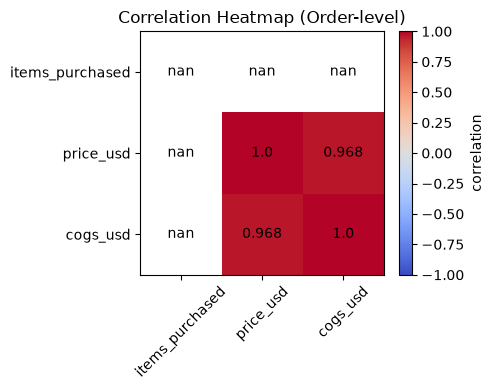

insights:
  - price_usd and cogs_usd are the most correlated pair (0.97).
  - The other variable pairs move fairly independently of each other.
  - This tells us whether bigger orders are simply higher-priced items, or a genuinely different customer behavior (more items, not pricier ones).


In [26]:
print("Q: Are order size (items purchased), price, and cost related to one another?")
numeric_cols = ['items_purchased', 'price_usd', 'cogs_usd']
correlation = orders[numeric_cols].corr().round(3)
print(correlation.to_string())
plt.figure(figsize=(5, 4))
plt.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='correlation')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, correlation.iloc[i, j], ha='center', va='center', color='black')
plt.title('Correlation Heatmap (Order-level)')
plt.tight_layout()
plt.show()
strongest_pair = correlation.where(~np.eye(len(numeric_cols), dtype=bool)).abs().stack().idxmax()
insights([
    f"{strongest_pair[0]} and {strongest_pair[1]} are the most correlated pair ({correlation.loc[strongest_pair]:.2f}).",
    "The other variable pairs move fairly independently of each other.",
    "This tells us whether bigger orders are simply higher-priced items, or a genuinely different customer behavior (more items, not pricier ones).",
])

### 2.3 Product Diagnostics

Q: Which products carry the highest refund risk?
              product_name  units_sold  units_refunded  refund_amount  refund_rate_pct
  The Birthday Sugar Panda        4985             301       15046.99             6.04
    The Original Mr. Fuzzy       24226            1237       61837.63             5.11
     The Forever Love Bear        5796             129        6448.71             2.23
The Hudson River Mini bear        5018              64        3199.36             1.28


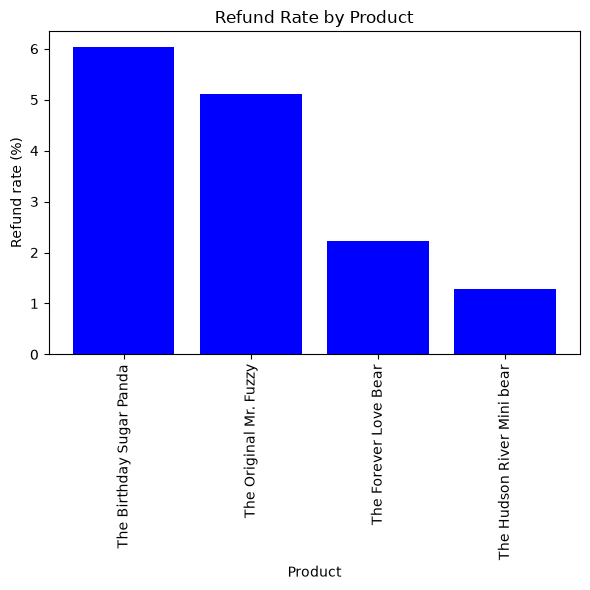

insights:
  - The Birthday Sugar Panda has the highest refund rate (6.04% of units sold) — likely a quality, sizing, or expectation-setting issue.
  - The Hudson River Mini bear has the lowest refund rate (1.28%) — worth reviewing what it does right (listing, packaging, QC).
  - Products with high revenue AND high refund rate deserve priority review — they carry both upside and risk.


In [27]:
print("Q: Which products carry the highest refund risk?")
items_with_product = order_items.merge(products, on='product_id')
items_with_refund = items_with_product.merge(refunds[['order_item_id', 'refund_amount_usd']], on='order_item_id', how='left')
items_with_refund['was_refunded'] = items_with_refund['refund_amount_usd'].notna()
refund_rate_by_product = items_with_refund.groupby('product_name').agg(
    units_sold=('order_item_id', 'nunique'), units_refunded=('was_refunded', 'sum'),
    refund_amount=('refund_amount_usd', 'sum')).reset_index()
refund_rate_by_product['refund_rate_pct'] = (refund_rate_by_product['units_refunded'] / refund_rate_by_product['units_sold'] * 100).round(2)
refund_rate_by_product = refund_rate_by_product.sort_values('refund_rate_pct', ascending=False)
print(refund_rate_by_product.to_string(index=False))
plt.figure(figsize=(6, 6))
plt.bar(refund_rate_by_product['product_name'], refund_rate_by_product['refund_rate_pct'], color='blue')
plt.title('Refund Rate by Product')
plt.xlabel('Product')
plt.ylabel('Refund rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
worst_refund = refund_rate_by_product.iloc[0]
best_refund = refund_rate_by_product.iloc[-1]
insights([
    f"{worst_refund['product_name']} has the highest refund rate ({worst_refund['refund_rate_pct']}% of units sold) — likely a quality, sizing, or expectation-setting issue.",
    f"{best_refund['product_name']} has the lowest refund rate ({best_refund['refund_rate_pct']}%) — worth reviewing what it does right (listing, packaging, QC).",
    "Products with high revenue AND high refund rate deserve priority review — they carry both upside and risk.",
])

### 2.4 Traffic & Channel Diagnostics

In [28]:
merged_grp = sessions.merge(orders[['order_id', 'website_session_id']], on='website_session_id', how='left')

utm_source  sessions  orders  conversion_rate_pct
   unknown     83328    6118                 7.34
   bsearch     62823    4519                 7.19
   gsearch    316035   21333                 6.75
socialbook     10685     343                 3.21


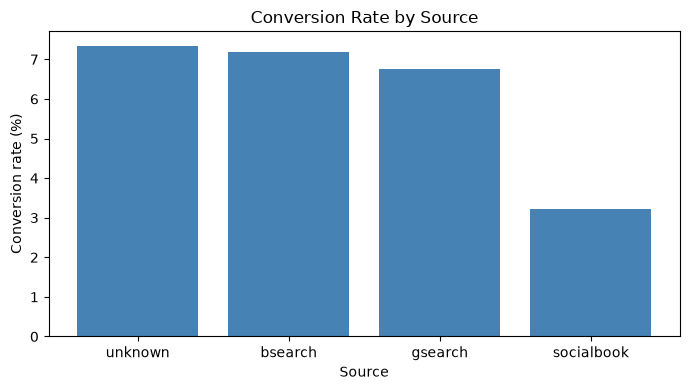

insights:
  - unknown converts best (7.34%).
  - socialbook converts worst (3.21%).
  - Traffic quality/intent differs meaningfully by channel — budget should weight toward the higher-converting sources, not just the highest-volume ones.


In [29]:
'''Q: Why do some acquisition channels convert better than others?'''
conversion_by_source = merged_grp.groupby('utm_source').agg(
    sessions=('website_session_id', 'nunique'), orders=('order_id', 'nunique')).reset_index()
conversion_by_source['conversion_rate_pct'] = (conversion_by_source['orders'] / conversion_by_source['sessions'] * 100).round(2)
conversion_by_source = conversion_by_source.sort_values('conversion_rate_pct', ascending=False)
print(conversion_by_source.to_string(index=False))
plt.figure(figsize=(7, 4))
plt.bar(conversion_by_source['utm_source'], conversion_by_source['conversion_rate_pct'], color='steelblue')
plt.title('Conversion Rate by Source')
plt.xlabel('Source')
plt.ylabel('Conversion rate (%)')
plt.tight_layout()
plt.show()
best_conv_source = conversion_by_source.iloc[0]
worst_conv_source = conversion_by_source.iloc[-1]
insights([
    f"{best_conv_source['utm_source']} converts best ({best_conv_source['conversion_rate_pct']}%).",
    f"{worst_conv_source['utm_source']} converts worst ({worst_conv_source['conversion_rate_pct']}%).",
    "Traffic quality/intent differs meaningfully by channel — budget should weight toward the higher-converting sources, not just the highest-volume ones.",
])

device_type  sessions  orders  conversion_rate_pct
    desktop    327027   27805                 8.50
     mobile    145844    4508                 3.09


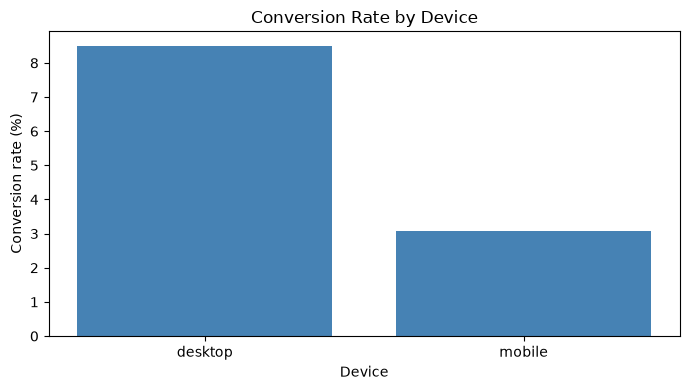

insights:
  - desktop converts best (8.5%).
  - mobile converts worst (3.09%).
  - Points to a UX or checkout friction gap between devices — worth a UX audit on the weaker-converting device.


In [30]:
'''Q: Why does one device type convert better than another?'''
conversion_by_device = merged_grp.groupby('device_type').agg(
    sessions=('website_session_id', 'nunique'), orders=('order_id', 'nunique')).reset_index()
conversion_by_device['conversion_rate_pct'] = (conversion_by_device['orders'] / conversion_by_device['sessions'] * 100).round(2)
conversion_by_device = conversion_by_device.sort_values('conversion_rate_pct', ascending=False)
print(conversion_by_device.to_string(index=False))
plt.figure(figsize=(7, 4))
plt.bar(conversion_by_device['device_type'], conversion_by_device['conversion_rate_pct'], color='steelblue')
plt.title('Conversion Rate by Device')
plt.xlabel('Device')
plt.ylabel('Conversion rate (%)')
plt.tight_layout()
plt.show()
best_conv_device = conversion_by_device.iloc[0]
worst_conv_device = conversion_by_device.iloc[-1]
insights([
    f"{best_conv_device['device_type']} converts best ({best_conv_device['conversion_rate_pct']}%).",
    f"{worst_conv_device['device_type']} converts worst ({worst_conv_device['conversion_rate_pct']}%).",
    "Points to a UX or checkout friction gap between devices — worth a UX audit on the weaker-converting device.",
])

                   stage  sessions  pct_of_landed
Landed (session started)    472871         100.00
           Viewed a page    472871         100.00
         Placed an order     32313           6.83


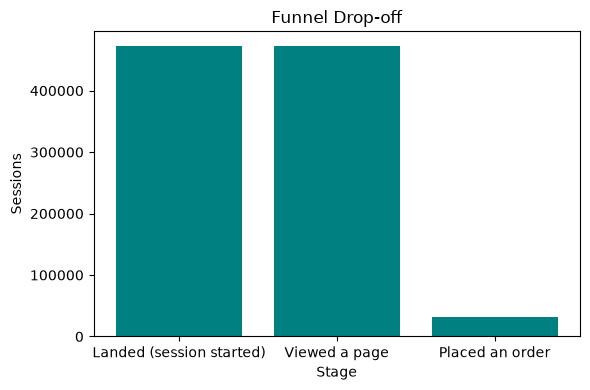

insights:
  - Biggest drop-off happens between 'viewed a page -> placed an order'.
  - Landed -> Viewed a page loses 0.0% of sessions.
  - Viewed a page -> Placed an order loses 93.2% of sessions.
  - That's the stage to prioritize for fixes (e.g. page load speed for the first drop, checkout friction for the second).


In [32]:
'''Q: Where in the user journey (funnel) are we losing the most sessions?'''
total_session_f = sessions['website_session_id'].nunique()
sessions_with_pageview = website_pageviews['website_session_id'].nunique()
sessions_with_order = orders['website_session_id'].nunique()
funnel = pd.DataFrame({
    'stage': ["Landed (session started)", "Viewed a page", "Placed an order"],
    'sessions': [total_session_f, sessions_with_pageview, sessions_with_order],
})
funnel['pct_of_landed'] = (funnel['sessions'] / total_session_f * 100).round(2)
print(funnel.to_string(index=False))
plt.figure(figsize=(6, 4))
plt.bar(funnel['stage'], funnel['sessions'], color='teal')
plt.title('Funnel Drop-off')
plt.xlabel('Stage')
plt.ylabel('Sessions')
plt.tight_layout()
plt.show()
drop_pageview = 100 - funnel.loc[1, 'pct_of_landed']
drop_order = funnel.loc[1, 'pct_of_landed'] - funnel.loc[2, 'pct_of_landed']
biggest_drop_stage = 'landed -> viewed a page' if drop_pageview > drop_order else 'viewed a page -> placed an order'
insights([
    f"Biggest drop-off happens between '{biggest_drop_stage}'.",
    f"Landed -> Viewed a page loses {drop_pageview:.1f}% of sessions.",
    f"Viewed a page -> Placed an order loses {drop_order:.1f}% of sessions.",
    "That's the stage to prioritize for fixes (e.g. page load speed for the first drop, checkout friction for the second).",
])

### 2.5 Customer Diagnostics

 is_repeat_session  sessions  orders  conversion_rate_pct
                 1     78553    6149                 7.83
                 0    394318   26164                 6.64


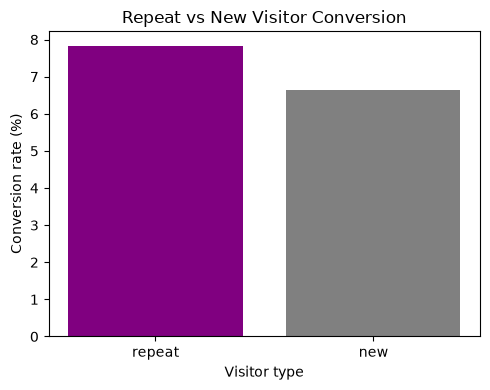

insights:
  - Repeat visitors convert at 7.83% vs 6.64% for new visitors.
  - That's a 1.19 percentage-point gap.
  - Familiarity/trust is clearly driving conversion — retention efforts (email, loyalty) are worth the investment.


In [33]:
'''Q: Why do repeat visitors behave differently from new visitors?'''
repeat_vs_new = merged_grp.groupby('is_repeat_session').agg(
    sessions=('website_session_id', 'nunique'), orders=('order_id', 'nunique')).reset_index()
repeat_vs_new['conversion_rate_pct'] = (repeat_vs_new['orders'] / repeat_vs_new['sessions'] * 100).round(2)
repeat_vs_new = repeat_vs_new.sort_values('conversion_rate_pct', ascending=False)
print(repeat_vs_new.to_string(index=False))
labels = ['repeat' if v == 1 else 'new' for v in repeat_vs_new['is_repeat_session']]
plt.figure(figsize=(5, 4))
plt.bar(labels, repeat_vs_new['conversion_rate_pct'], color=['purple', 'grey'])
plt.title('Repeat vs New Visitor Conversion')
plt.xlabel('Visitor type')
plt.ylabel('Conversion rate (%)')
plt.tight_layout()
plt.show()
repeat_row = repeat_vs_new[repeat_vs_new['is_repeat_session'] == 1].iloc[0]
new_row = repeat_vs_new[repeat_vs_new['is_repeat_session'] == 0].iloc[0]
gap = repeat_row['conversion_rate_pct'] - new_row['conversion_rate_pct']
insights([
    f"Repeat visitors convert at {repeat_row['conversion_rate_pct']}% vs {new_row['conversion_rate_pct']}% for new visitors.",
    f"That's a {gap:.2f} percentage-point gap.",
    f"{'Familiarity/trust is clearly driving conversion — retention efforts (email, loyalty) are worth the investment' if gap > 0 else 'Repeat visits are not translating into a conversion advantage yet — worth investigating why'}.",
])

### 2.6 Refund Diagnostics

Q: Is the refund trend proportional to order volume, or spiking independently?
  month  refund_amount_usd  order_count   revenue  refund_rate_pct
2012-04             249.95           99   4949.01             5.05
2012-05             249.95          108   5398.92             4.63
2012-06             249.95          140   6998.60             3.57
2012-07             649.87          169   8448.31             7.69
2012-08             899.82          228  11397.72             7.89
2012-09            1049.79          287  14347.13             7.32
2012-10            1199.76          371  18546.29             6.47
2012-11            1999.60          618  30893.82             6.47
2012-12            1899.62          506  25294.94             7.51
2013-01            1049.79          390  19966.10             5.26
2013-02            1149.77          498  26515.02             4.34
2013-03            1049.79          385  19896.15             5.28
2013-04            1149.77          553  28584.47 

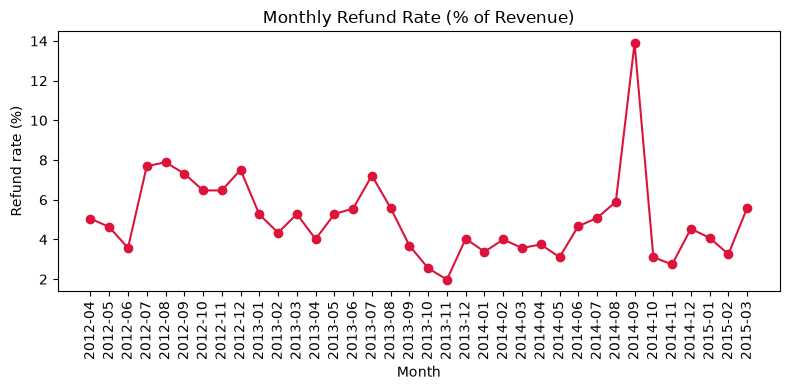

insights:
  - Average monthly refund rate is 5.06% of revenue.
  - 2014-09 spiked to 13.89% — well above the average, an anomaly worth investigating.
  - Cross-check this against the Product Diagnostics section — a spike often traces back to one specific product batch.


In [34]:
print("Q: Is the refund trend proportional to order volume, or spiking independently?")
refund_vs_orders = monthly_refunds.merge(
    order_trend.rename(columns={'created_at': 'month'}), on='month', how='inner')
refund_vs_orders['refund_rate_pct'] = (refund_vs_orders['refund_amount_usd'] / refund_vs_orders['revenue'] * 100).round(2)
print(refund_vs_orders.to_string(index=False))
plt.figure(figsize=(8, 4))
plt.plot(refund_vs_orders['month'], refund_vs_orders['refund_rate_pct'], marker='o', color='crimson')
plt.title('Monthly Refund Rate (% of Revenue)')
plt.xlabel('Month')
plt.ylabel('Refund rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
worst_refund_rate_month = refund_vs_orders.loc[refund_vs_orders['refund_rate_pct'].idxmax()]
avg_refund_rate = refund_vs_orders['refund_rate_pct'].mean()
insights([
    f"Average monthly refund rate is {avg_refund_rate:.2f}% of revenue.",
    f"{worst_refund_rate_month['month']} spiked to {worst_refund_rate_month['refund_rate_pct']}% — "
    f"{'well above the average, an anomaly worth investigating' if worst_refund_rate_month['refund_rate_pct'] > avg_refund_rate * 1.5 else 'roughly in line with the normal range'}.",
    "Cross-check this against the Product Diagnostics section — a spike often traces back to one specific product batch.",
])

### SECTION 2 SUMMARY — Diagnostic Analysis

In [35]:
print("Q: Overall, what's driving the patterns we saw in the descriptive numbers?")
insights([
    f"Revenue is {'largely a traffic/volume story' if traffic_revenue_corr > 0.7 else 'not fully explained by traffic alone'} "
    f"(sessions-vs-revenue correlation: {traffic_revenue_corr:.2f}).",
    f"{best_conv_source['utm_source']} is both a top revenue channel and the best converter — {worst_conv_source['utm_source']} "
    f"converts worst and deserves review.",
    f"{best_conv_device['device_type']} converts better than {worst_conv_device['device_type']} — a device-specific UX gap.",
    f"Biggest funnel drop-off: '{biggest_drop_stage}'.",
    f"{worst_refund['product_name']} carries the highest refund risk — pair this with its revenue rank to prioritize action.",
    "Together these point to three levers worth acting on: channel budget reallocation, device UX parity, and "
    "quality review on the highest-refund product.",
])


# ============================================================
# SECTION 3 - PREDICTIVE ANALYSIS (what's likely to happen)
#   - OneHotEncoder only for categorical encoding
# The encoder is called directly and its output is combined with the plain
# numeric column by hand — every step is visible, nothing is hidden inside a
# wrapper object.
# ============================================================

Q: Overall, what's driving the patterns we saw in the descriptive numbers?
insights:
  - Revenue is largely a traffic/volume story (sessions-vs-revenue correlation: 0.98).
  - unknown is both a top revenue channel and the best converter — socialbook converts worst and deserves review.
  - desktop converts better than mobile — a device-specific UX gap.
  - Biggest funnel drop-off: 'viewed a page -> placed an order'.
  - The Birthday Sugar Panda carries the highest refund risk — pair this with its revenue rank to prioritize action.
  - Together these point to three levers worth acting on: channel budget reallocation, device UX parity, and quality review on the highest-refund product.


## SECTION 3: PREDICTIVE ANALYSIS

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, roc_auc_score,
                              recall_score, f1_score, confusion_matrix, classification_report)

'''Q: Can we predict, from a session's channel/campaign/device/visitor-type, whether it will convert?'''

In [37]:
converted_ids = set(orders['website_session_id'].dropna())
sessions['converted'] = sessions['website_session_id'].isin(converted_ids).astype(int)

categorical_features = ['utm_source', 'utm_campaign', 'device_type']
binary_features = ['is_repeat_session']
target = 'converted'

keep_cols = ['website_session_id'] + categorical_features + binary_features + [target]
dataset = sessions[keep_cols].dropna(subset=categorical_features + binary_features)

print('session dataset shape:', dataset.shape)
print('baseline conversion rate: {:.2f}%'.format(dataset[target].mean() * 100))

session dataset shape: (472871, 6)
baseline conversion rate: 6.83%


In [38]:
# --- Encode the categorical columns with OneHotEncoder directly ---
encoder = OneHotEncoder(handle_unknown='ignore')
X_cat = encoder.fit_transform(dataset[categorical_features]).toarray()
X_bin = dataset[binary_features].to_numpy()
X = np.hstack([X_cat, X_bin])
y = dataset[target].to_numpy()

print('encoded categories:', encoder.categories_)
print('final feature matrix shape:', X.shape)

encoded categories: [array(['bsearch', 'gsearch', 'socialbook', 'unknown'], dtype=object), array(['brand', 'desktop_targeted', 'nonbrand', 'pilot', 'unknown'],
      dtype=object), array(['desktop', 'mobile'], dtype=object)]
final feature matrix shape: (472871, 12)


In [39]:
# --- Train/test split (stratified — conversion is a minority class) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
# --- Fit logistic regression directly — no wrapping in a Pipeline ---
# class_weight="balanced" matters — most sessions do NOT convert, and an
# unweighted model would just predict "no" for every session.
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [41]:
# --- Evaluate ---
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print('\n====== model evaluation ======')
print('train rows:', len(X_train), '| test rows:', len(X_test))
print('Accuracy:', round(accuracy, 4))
print('Precision:', round(precision, 4))
print('ROC-AUC:', round(roc_auc, 4))
print('Recall:', round(recall, 4))
print('F1:', round(f1, 4))
print('\nConfusion matrix [[TN, FP], [FN, TP]]:')
print(cm)
print('\n' + classification_report(y_test, y_pred, zero_division=0))


====== model evaluation ======
train rows: 378296 | test rows: 94575
Accuracy: 0.369
Precision: 0.0857
ROC-AUC: 0.6077
Recall: 0.8519
F1: 0.1558

Confusion matrix [[TN, FP], [FN, TP]]:
[[29396 58716]
 [  957  5506]]

              precision    recall  f1-score   support

           0       0.97      0.33      0.50     88112
           1       0.09      0.85      0.16      6463

    accuracy                           0.37     94575
   macro avg       0.53      0.59      0.33     94575
weighted avg       0.91      0.37      0.47     94575



In [42]:
insights([
    f"The model ranks conversion likelihood with an ROC-AUC of {roc_auc:.2f}",
    f"Precision is {precision:.2%} and recall is {recall:.2%}",
    "Channel, campaign, device, and repeat-visitor status alone only weakly predict an individual session's conversion.",
    "Best used for relative scoring/targeting (e.g. rank sessions by predicted probability) rather than confident yes/no calls.",
])

insights:
  - The model ranks conversion likelihood with an ROC-AUC of 0.61
  - Precision is 8.57% and recall is 85.19%
  - Channel, campaign, device, and repeat-visitor status alone only weakly predict an individual session's conversion.
  - Best used for relative scoring/targeting (e.g. rank sessions by predicted probability) rather than confident yes/no calls.


In [43]:
# --- Save model + encoder so the Streamlit app can transform new input the
# exact same way -
import pickle

model_bundle = {
    'model': model,
    'encoder': encoder,
    'categorical_features': categorical_features,
    'binary_features': binary_features,
}
with open("conversion_model.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

print("\nModel bundle saved to conversion_model.pkl")


Model bundle saved to conversion_model.pkl


### SECTION 3 SUMMARY — Predictive Analysis

In [44]:
print("Q: Overall, how reliable and useful is this model for the business?")
insights([
    f" conversion rate in the data is {dataset[target].mean() * 100:.2f}%.",
    f"Logistic Regression on utm_source, utm_campaign, device_type (one-hot encoded) + is_repeat_session ",
    f"achieves ROC-AUC {roc_auc:.2f}, precision {precision:.2%}, recall {recall:.2%}.",
])

print("\nPipeline complete.")

Q: Overall, how reliable and useful is this model for the business?
insights:
  -  conversion rate in the data is 6.83%.
  - Logistic Regression on utm_source, utm_campaign, device_type (one-hot encoded) + is_repeat_session 
  - achieves ROC-AUC 0.61, precision 8.57%, recall 85.19%.

Pipeline complete.
